In [1]:

from langchain_google_genai import GoogleGenerativeAIEmbeddings,ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.prebuilt import ToolNode, tools_condition

KeyboardInterrupt: 

In [ ]:

load_dotenv()

True

In [ ]:
llm = ChatGoogleGenerativeAI(
model="gemini-2.5-flash",
# temperature=0.2,
# max_tokens=100,   
# timeout=None,
# max_retries=2,
# other params...
)

In [ ]:
loader = PyPDFLoader("123.pdf")
docs = loader.load()

In [ ]:

len(docs)

1

In [ ]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [ ]:
len(chunks)

3

In [ ]:
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001"
)
vector_store = FAISS.from_documents(chunks,embeddings)



In [ ]:
vector_store

In [ ]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [ ]:
@tool
def rag_tool(query):
    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """

    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        "query": query,
        "context": context,
        "metadata": metadata
    }

In [ ]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [ ]:
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage], add_messages]

In [ ]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [ ]:
tool_node = ToolNode(tools)

In [ ]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

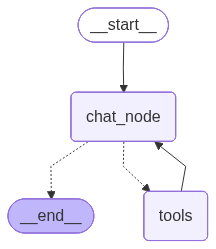

In [ ]:
chatbot

In [ ]:
result = chatbot.invoke(
    {
        "messages": [   # ✅ plural
            HumanMessage(
                content="Using the pdf notes, get me the basic details of the person"
            )
        ]
    }
)

# Display the final response


ValidationError: 1 validation error for Schema
properties.query
  Input should be a valid dictionary or object to extract fields from [type=model_attributes_type, input_value=None, input_type=NoneType]
    For further information visit https://errors.pydantic.dev/2.12/v/model_attributes_type

In [ ]:
pip install langgraph-checkpoint-postgres psycopg[binary,pool]

   ---------------------------------------- 0.0/3.6 MB ? eta -:--:--
   -------------------------------------- - 3.4/3.6 MB 16.1 MB/s eta 0:00:01
   ---------------------------------------- 3.6/3.6 MB 12.1 MB/s  0:00:00

   ---------------------------------------- 0/4 [psycopg-pool]
   ---------------------------------------- 0/4 [psycopg-pool]
   ---------------------------------------- 0/4 [psycopg-pool]
   ---------- ----------------------------- 1/4 [psycopg-binary]
   -------------------- ------------------- 2/4 [psycopg]
   -------------------- ------------------- 2/4 [psycopg]
   -------------------- ------------------- 2/4 [psycopg]
   -------------------- ------------------- 2/4 [psycopg]
   -------------------- ------------------- 2/4 [psycopg]
   -------------------- ------------------- 2/4 [psycopg]
   -------------------- ------------------- 2/4 [psycopg]
   -------------------- ------------------- 2/4 [psycopg]
   -------------------- ------------------- 2/4 [psycopg]
   